# PharmIQ — Exploratory Data Analysis
**Dataset:** Tata 1mg Medicine Data (273K+ records)
**Objective:** Understand MRP distribution, dosage form breakdown, manufacturer landscape, and salt composition patterns.

In [1]:
import os, sys
os.chdir('..')
sys.path.insert(0, os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Environment ready')

Environment ready


In [3]:
import os, sys
os.chdir('..')
sys.path.insert(0, os.getcwd())

print(os.getcwd())          # confirm this prints your project root
print(os.path.exists('src')) # should print True

c:\Users\faffo\Project\ML_PharmIQ
True


## 1. Load & Inspect

In [4]:
from src.data.ingest import load_raw, clean, validate

df_raw = load_raw('data/raw/tata_1mg_Medicine_data.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (273929, 7)


,Index,Name,MRP,Quantity,Manufacturer,Salt_Composition,Image_URL
0,0,Ascabiol Emulsion,115.36,bottle of 60 ml Solution,Abbott,Lindane (1% w/v) + Cetrimide (0.1% w/v),"https://onemg.gumlet.io/a_ignore,w_380,h_380,c..."
1,1,Allegra Nasal Spray,479.00,bottle of 6 gm Nasal Spray,Sanofi India Ltd,Fluticasone Furoate (27.5mcg),"https://onemg.gumlet.io/a_ignore,w_380,h_380,c..."
2,2,Ache X Tablet,42.50,strip of 10 tablets,Affy Pharma Pvt Ltd,Chlorzoxazone (250mg) + Diclofenac (50mg) + Pa...,"https://onemg.gumlet.io/a_ignore,w_380,h_380,c..."
3,3,Advent Forte 457mg Syrup Tangy Orange,234.42,bottle of 30 ml Syrup,Cipla Ltd,Amoxycillin (400mg/5ml) + Clavulanic Acid (5...,"https://onemg.gumlet.io/a_ignore,w_380,h_380,c..."
4,4,Ace-Proxyvon CR Tablet,190.50,strip of 10 tablet cr,Dr Reddy's Laboratories Ltd,Aceclofenac (200mg) + Rabeprazole (20mg),"https://onemg.gumlet.io/a_ignore,w_380,h_380,c..."


In [5]:
print('Dtypes:')
print(df_raw.dtypes)
print()
print('Nulls:')
print(df_raw.isnull().sum())

Dtypes:
Index                 int64
Name                    str
MRP                 float64
Quantity                str
Manufacturer            str
Salt_Composition        str
Image_URL               str
dtype: object

Nulls:
Index               0
Name                0
MRP                 0
Quantity            0
Manufacturer        0
Salt_Composition    0
Image_URL           0
dtype: int64


In [6]:
df = clean(df_raw)
validate(df)
print(f'After cleaning: {df.shape}')

After cleaning: (273655, 7)


## 2. MRP Distribution

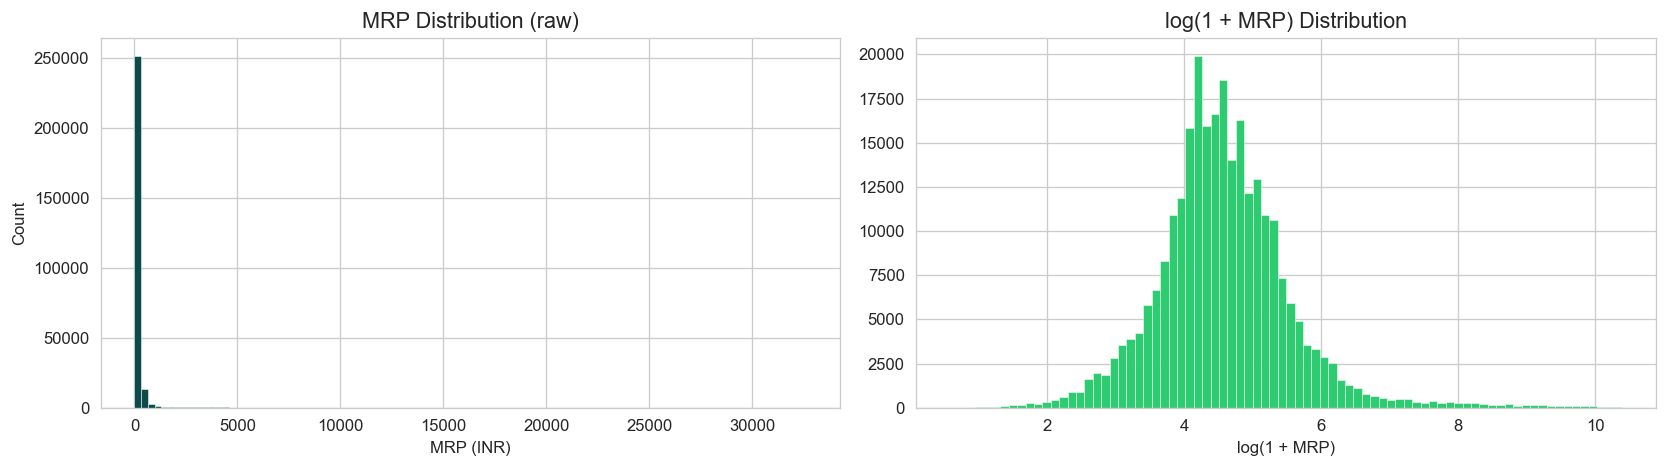

count    273655.00
mean        232.45
std        1116.12
min           0.80
25%          55.00
50%          90.00
75%         159.00
max       32650.00
Name: MRP, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw MRP
axes[0].hist(df['MRP'], bins=100, color='#0D4A4A', edgecolor='white', linewidth=0.3)
axes[0].set_title('MRP Distribution (raw)', fontsize=13)
axes[0].set_xlabel('MRP (INR)')
axes[0].set_ylabel('Count')

# Log MRP
axes[1].hist(np.log1p(df['MRP']), bins=80, color='#2ECC71', edgecolor='white', linewidth=0.3)
axes[1].set_title('log(1 + MRP) Distribution', fontsize=13)
axes[1].set_xlabel('log(1 + MRP)')

plt.tight_layout()
plt.savefig('artifacts/eda_mrp_distribution.png', bbox_inches='tight')
plt.show()

print(df['MRP'].describe().round(2))

## 3. Dosage Form Breakdown

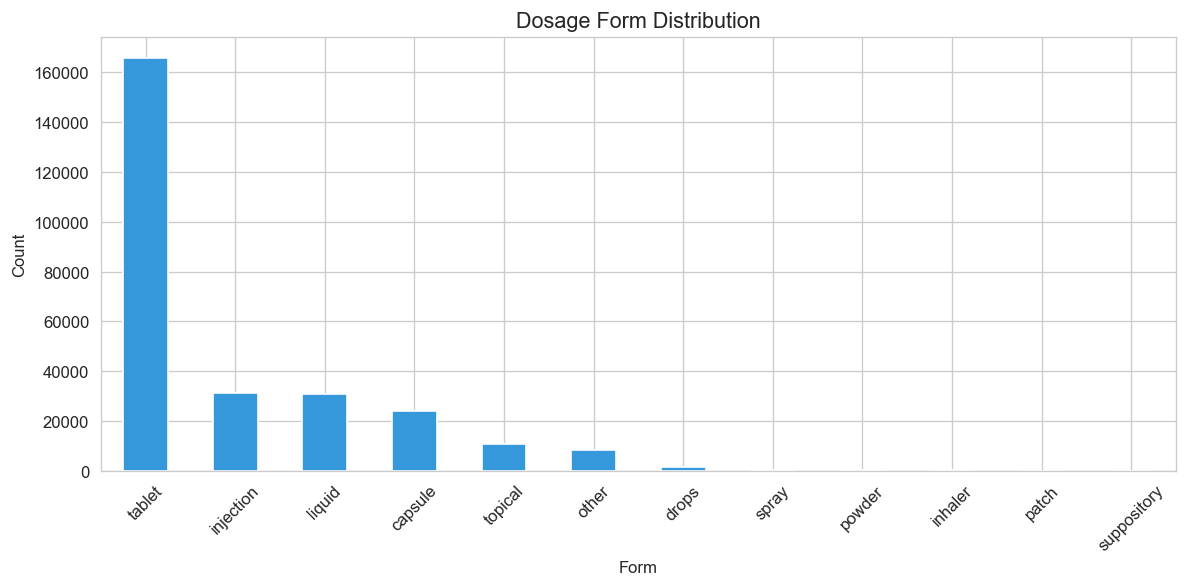

dosage_form
tablet         165826
injection       31071
liquid          30758
capsule         23832
topical         10764
other            8369
drops            1649
spray             503
powder            481
inhaler           277
patch              80
suppository        45
Name: count, dtype: int64


In [9]:
from src.features.engineer import extract_dosage_form

df['dosage_form'] = df['Quantity'].apply(extract_dosage_form)
form_counts = df['dosage_form'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
form_counts.plot(kind='bar', ax=ax, color='#3498DB', edgecolor='white')
ax.set_title('Dosage Form Distribution', fontsize=13)
ax.set_xlabel('Form')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('artifacts/eda_dosage_forms.png', bbox_inches='tight')
plt.show()

print(form_counts)

## 4. MRP by Dosage Form

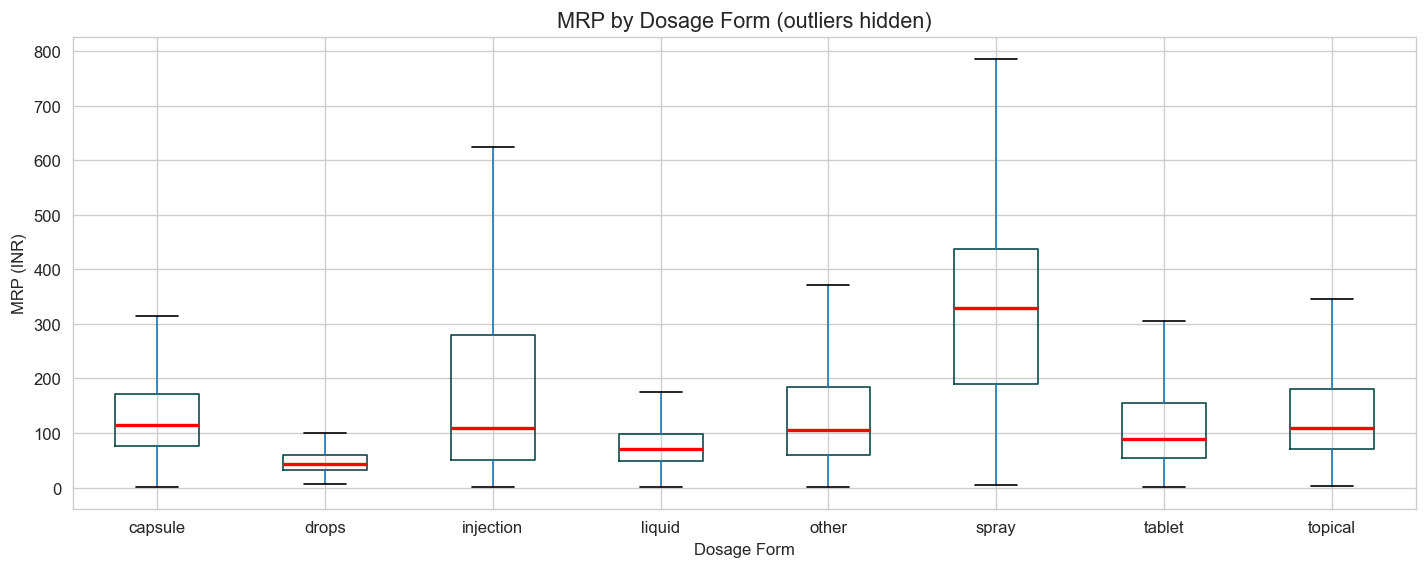

In [10]:
top_forms = form_counts.head(8).index.tolist()
df_top = df[df['dosage_form'].isin(top_forms)]

fig, ax = plt.subplots(figsize=(12, 5))
df_top.boxplot(column='MRP', by='dosage_form', ax=ax,
               boxprops=dict(color='#0D4A4A'),
               medianprops=dict(color='red', linewidth=2),
               showfliers=False)
ax.set_title('MRP by Dosage Form (outliers hidden)', fontsize=13)
ax.set_xlabel('Dosage Form')
ax.set_ylabel('MRP (INR)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('artifacts/eda_mrp_by_form.png', bbox_inches='tight')
plt.show()

## 5. Top Manufacturers

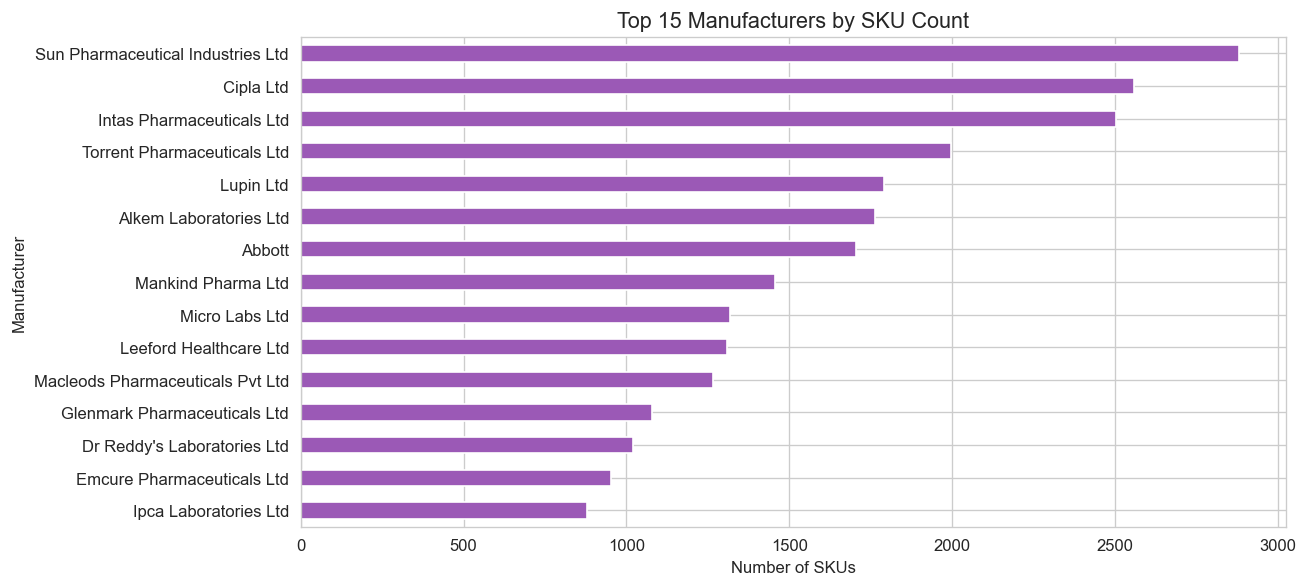

In [11]:
top_mfr = df['Manufacturer'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 5))
top_mfr.sort_values().plot(kind='barh', ax=ax, color='#9B59B6', edgecolor='white')
ax.set_title('Top 15 Manufacturers by SKU Count', fontsize=13)
ax.set_xlabel('Number of SKUs')
plt.tight_layout()
plt.savefig('artifacts/eda_top_manufacturers.png', bbox_inches='tight')
plt.show()

## 6. Salt Count Distribution

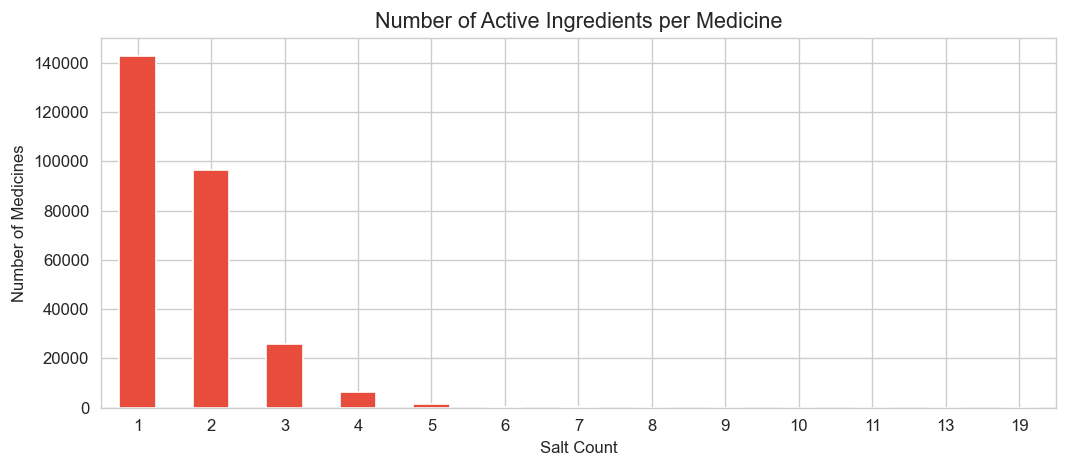

Multi-salt medicines: 47.8%


In [12]:
from src.features.engineer import extract_salt_count

df['salt_count'] = df['Salt_Composition'].apply(extract_salt_count)
salt_counts = df['salt_count'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
salt_counts.plot(kind='bar', ax=ax, color='#E74C3C', edgecolor='white')
ax.set_title('Number of Active Ingredients per Medicine', fontsize=13)
ax.set_xlabel('Salt Count')
ax.set_ylabel('Number of Medicines')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('artifacts/eda_salt_count.png', bbox_inches='tight')
plt.show()

pct_multi = (df['salt_count'] > 1).mean() * 100
print(f'Multi-salt medicines: {pct_multi:.1f}%')

## 7. Key Findings Summary

In [13]:
print('=== EDA KEY FINDINGS ===')
print(f'Total records        : {len(df):,}')
print(f'MRP range            : ₹{df["MRP"].min():.2f} – ₹{df["MRP"].max():,.2f}')
print(f'MRP median           : ₹{df["MRP"].median():.2f}')
print(f'Dosage forms         : {df["dosage_form"].nunique()}')
print(f'Unique manufacturers : {df["Manufacturer"].nunique():,}')
print(f'Multi-salt medicines : {pct_multi:.1f}%')
print(f'Dominant form        : tablet ({form_counts["tablet"]/len(df)*100:.1f}% of dataset)')

=== EDA KEY FINDINGS ===
Total records        : 273,655
MRP range            : ₹0.80 – ₹32,650.00
MRP median           : ₹90.00
Dosage forms         : 12
Unique manufacturers : 11,000
Multi-salt medicines : 47.8%
Dominant form        : tablet (60.6% of dataset)
